# Electron Diffraction

simply looking at the description, this should be pretty simple

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# organize data
v = [2.5E3 + (n * 0.5E3) for n in range(6)] # Anode High Voltages
y1 = [22.8E-3, 20.5E-3, 19.0E-3, 17.5E-3, 17.0E-3, 16.3E-3]
y2 = [32.8E-3, 29.9E-3, 27.1E-3, 25.3E-3, 23.8E-3, 22.2E-3]

In [73]:
# convert
h = 6.626E-34 # J•s
e = 1.602E-19 # A•s
m = 9.109E-31 # kg, rest mass
l = [h/np.sqrt(2*m*e*v[i]) for i in range(len(v))]
print(l)

# unc
v_unc = 0.1E3 # half of smallest interval
l_unc = -np.array(l)/2 * v_unc/np.array(v) # using unc prop formulae
print(l_unc) 

[2.4530128456020808e-11, 2.2392841156436615e-11, 2.073174243364304e-11, 1.9392769304383814e-11, 1.8283678241488162e-11, 1.7345420174629407e-11]
[-4.90602569e-13 -3.73214019e-13 -2.96167749e-13 -2.42409616e-13
 -2.03151980e-13 -1.73454202e-13]


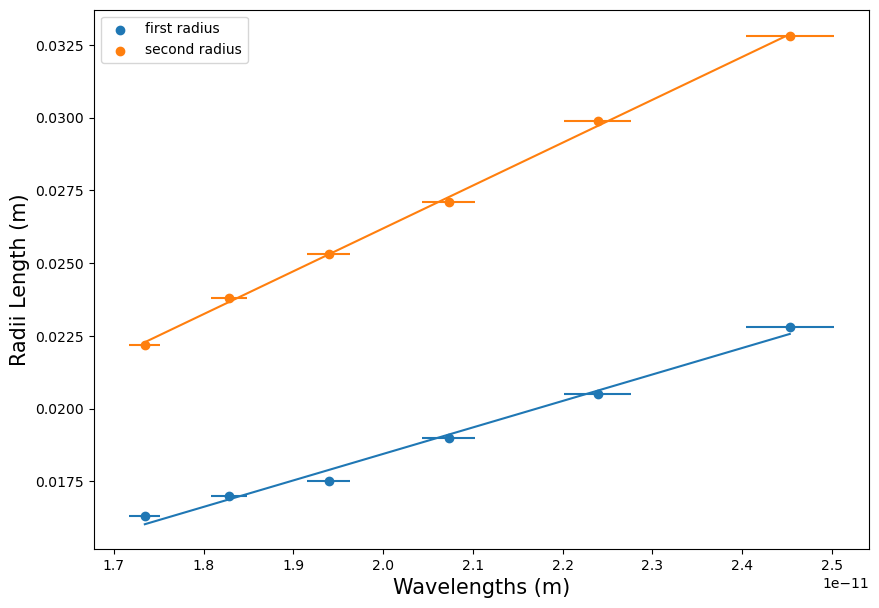

In [74]:
# plot
m = [0, 0]
b = [0, 0]

# make the data
x = np.array(l) # Wavelengths
y = np.array([y1, y2]) # radii
#y_r1 = np.array(y1) # 1st radii
#y_r2 = np.array(y2) # 2nd radii
    
# errorbars
# DO THESE
x_err = np.abs(l_unc)
y_err = 0.5E-4
    
# plot
fig, ax = plt.subplots()
    
ax.set_ylabel("Radii Length (m)", fontsize=15)
ax.set_xlabel("Wavelengths (m)", fontsize=15)

ax.scatter(x, y[0], label="first radius")
ax.scatter(x, y[1], label="second radius", color="tab:orange")
#ax.errorbar(x, y_r1, xerr=x_err, yerr=y_err, fmt='none')
ax.errorbar(x, y[0], xerr=x_err, yerr=y_err, fmt='none')
ax.errorbar(x, y[1], xerr=x_err, yerr=y_err, fmt='none', color="tab:orange")

# fit the lines
for i in range(0, len(m)):
    p = np.polyfit(x, y[i], 1)
    m[i] = p[0]
    b[i] = p[1]
ax.plot(x, m[0]*x+b[0])
ax.plot(x, m[1]*x+b[1], color="tab:orange")

# save
ax.legend()
fig.set_size_inches(10, 7)
name = "./radii.png"
fig.savefig(name, bbox_inches='tight', pad_inches=0.5)

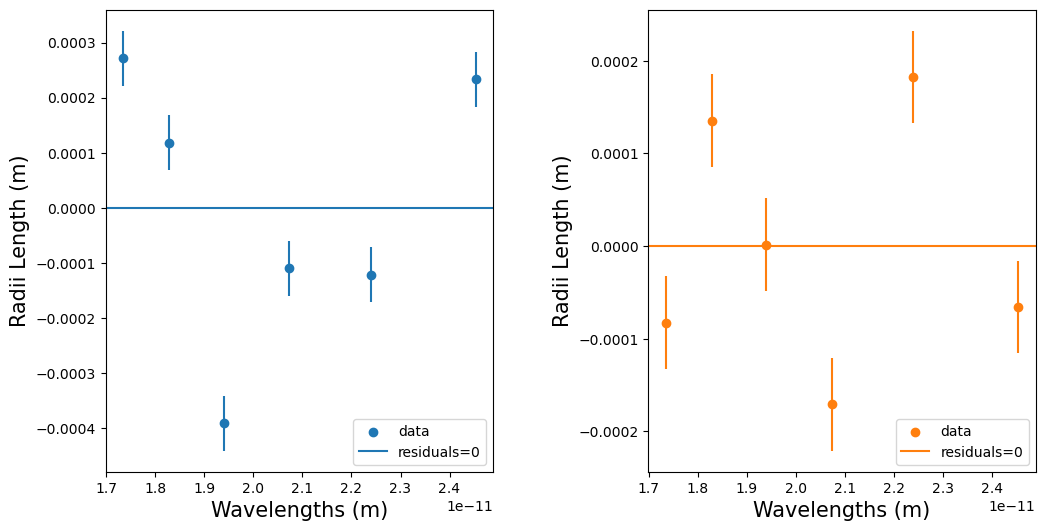

In [68]:
# residuals
fig, ax = plt.subplots(ncols=2)
plt.subplots_adjust(wspace=0.4)

# make the data
x = np.array(l) # Wavelengths
y = np.array([y1, y2]) # Radii
    
# DO THESE
#x_err = np.array(freq_unc)
y_err = 0.5E-4

# line of best fit
# - outliers already corrected for 0 and 8
fit = np.zeros((2, len(x)))
res = np.zeros((2, len(x)))
for i in range(0, len(m)):
    fit[i] = m[i]*x+b[i]
    res[i] = y[i]-fit[i]
    
# plot
colors = ["tab:blue", "tab:orange"]
for i in range(0, len(m)):
    ax[i].set_ylabel("Radii Length (m)", fontsize=15)
    ax[i].set_xlabel("Wavelengths (m)", fontsize=15)
    
    ax[i].scatter(x, res[i], label="data", color=colors[i])
    ax[i].errorbar(x, res[i], yerr=y_err, fmt='none', color=colors[i])
    ax[i].axhline(y=0, label="residuals=0", color=colors[i])
    
    ax[i].legend(loc='lower right')

# save
fig.set_size_inches(12, 6)
name = "./radii_res.png"
fig.savefig(name, bbox_inches='tight', pad_inches=0.5)

In [32]:
# uncertainties for fit

m_unc = [0, 0]
b_unc = [0, 0]
for i in range(0, len(m)):
    N = len(l)-1
    delta = np.abs(N*np.sum(x**2) - np.sum(x)**2)
    covar = np.sum((y[i]-(b[i]+m[i]*x))**2)/(N-2)
    m_unc[i] = np.sqrt(N*covar/delta)
    b_unc[i] = np.sqrt(covar*np.sum(x**2)/delta)

    print(m[i], "±", m_unc[i])
    print(b[i], "±", b_unc[i])
    print()

910032385.1781372 ± 15188462.782808278
0.00024338991825055456 ± 0.0003426139944858588

1473003013.4435294 ± 8110583.714549313
-0.0032671619458583268 ± 0.00018295462311031235



In [77]:
# linear correlation coefficient
x = np.array(l) # Wavelengths
y = np.array([y1, y2]) # radii

r = np.corrcoef(x, y[0])
print(r)
r = np.corrcoef(x, y[1])
print(r)

[[1.         0.99463093]
 [0.99463093 1.        ]]
[[1.         0.99941142]
 [0.99941142 1.        ]]


In [88]:
# chi-squared test for goodness of fit

x = np.array(l) # Wavelengths
y = np.array([y1, y2]) # radii
y_avg = [np.mean(y[0]), np.mean(y[1])]
fit = np.zeros((2, len(x)))
for i in range(0, len(m)):
    fit[i] = m[i]*x+b[i]

x_err = np.abs(l_unc)
y_err = 0.5E-4
# update y_err assuming linear fit and using error prop
yerr_new = np.zeros((2, len(x)))
for i in range(0, len(m)):
    yerr_new[i] = np.sqrt(m[i]**2 * x[i]**2 * ((m_unc[i]/m[i])**2 + (x_err/x[i])**2) + b_unc[i]**2)

chisq = [0, 0]
redchisq = [0, 0]
N = len(l)
print(y)
print(y_avg)
print(fit)
print()

for j in range(0, len(m)):
    chisq[j] = np.sum(((y[j]-fit[j]) / y_err)**2)
    redchisq[j] = chisq[j]/(N-2)

print(N)
print(chisq)
print(redchisq)
print()

# alternatively, propogating x errors to y
for j in range(0, len(m)):
    chisq[j] = np.sum(((y[j]-fit[j]) / yerr_new[i])**2)
    redchisq[j] = chisq[j]/(N-2)
print(N)
print(chisq)
print(redchisq)
print()

[[0.0228 0.0205 0.019  0.0175 0.017  0.0163]
 [0.0328 0.0299 0.0271 0.0253 0.0238 0.0222]]
[0.018850000000000002, 0.026850000000000002]
[[0.0225666  0.0206216  0.01910995 0.01789144 0.01688213 0.01602828]
 [0.03286579 0.02971756 0.02727076 0.02529845 0.02366475 0.02228269]]

6
[128.91873399795898, 36.76144820211901]
[32.229683499489745, 9.190362050529753]

6
[1.6191967199875124, 0.38036202350249737]
[0.4047991799968781, 0.09509050587562434]

